## Classification Exploration 2: Decision Tree

# [Classification: Decision Tree](https://en.wikipedia.org/wiki/Decision_tree_learning)

The IBM HR Analytics Employee Attrition dataset contains fictional data created by IBM data scientists. 
It includes 1,470 employee records with 35 features covering demographics, job roles, satisfaction levels, 
and compensation. The target variable is **Attrition** — whether an employee left the company (Yes/No).

In [31]:
import pandas as pd

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [8]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


Attrition
No     1233
Yes     237
dtype: int64


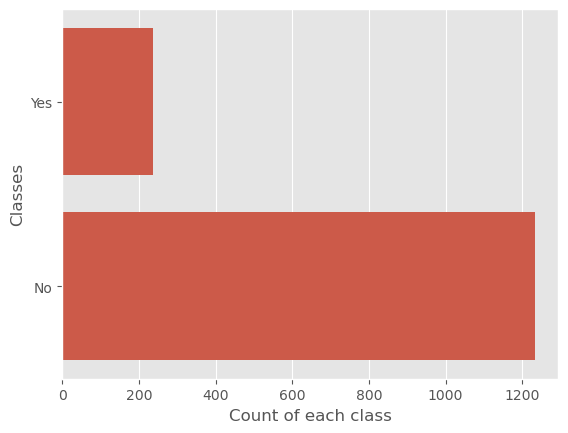

In [9]:
#Print class frequency through pandas
print(df.groupby('Attrition').size())

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

sns.countplot(y=df['Attrition'], data=df)
plt.xlabel("Count of each class")
plt.ylabel("Classes")
plt.show()

In [10]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Data Preparation

In [5]:
# Drop constant columns — they add no information
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'])

# Encode categorical columns
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',
                                  'Gender', 'JobRole', 'MaritalStatus', 'OverTime'],
                    drop_first=True)

# Encode target variable: Yes → 1, No → 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [11]:
# Drop constant columns — they add no information
df = df.drop(columns=['EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'])

# Encode categorical columns
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField',
                                  'Gender', 'JobRole', 'MaritalStatus', 'OverTime'],
                    drop_first=True)

# Encode target variable: Yes → 1, No → 0
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

### Separate Train/Test sets

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.30,
                                                     stratify=y,
                                                     random_state=123)

print(X_train.shape, X_test.shape)

(1029, 44) (441, 44)


## The Decision Tree Model

In [13]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(criterion='gini', max_depth=10, min_samples_split=2, min_samples_leaf=2)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# criterion: "gini" or "entropy"
# max_depth: maximum depth of the tree
# min_samples_split: minimum samples required to split a node
# min_samples_leaf: minimum samples required at a leaf node

In [14]:
y_pred

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

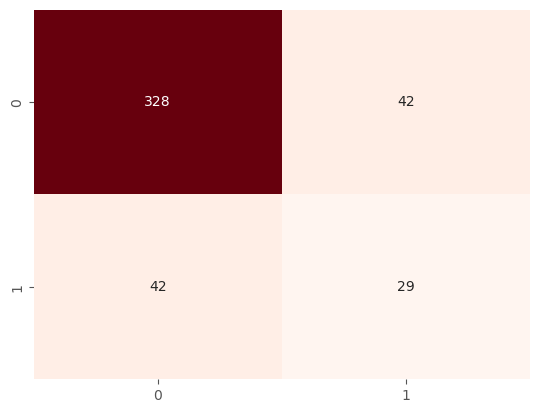

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Reds", cbar=False)
plt.show()

In [16]:
from sklearn import metrics

print('***RESULTS ON TEST SET***')
print("f1_score: ", metrics.f1_score(y_test, y_pred))
print("precision: ", metrics.precision_score(y_test, y_pred))
print("recall: ", metrics.recall_score(y_test, y_pred))
print("accuracy: ", metrics.accuracy_score(y_test, y_pred))

***RESULTS ON TEST SET***
f1_score:  0.4084507042253521
precision:  0.4084507042253521
recall:  0.4084507042253521
accuracy:  0.8095238095238095


## Searching the Best Parameters

In [17]:
#DEFINE YOUR CLASSIFIER and THE PARAMETERS GRID
from sklearn.tree import DecisionTreeClassifier
import numpy as np

classifier = DecisionTreeClassifier()
parameters = {'criterion': ['entropy', 'gini'],
              'max_depth': [3, 5, 10, 50],
              'min_samples_split': [5, 10],
              'min_samples_leaf': [2, 4]}

In [18]:
#DEFINE YOUR GRIDSEARCH
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(classifier, parameters, cv=3, scoring='f1', verbose=10, n_jobs=-1)

In [19]:
#TRAIN YOUR CLASSIFIER
gs = gs.fit(X_train, y_train)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
[CV 3/3; 2/32] START criterion=entropy, max_depth=3, min_samples_leaf=2, min_samples_split=10
[CV 3/3; 2/32] END criterion=entropy, max_depth=3, min_samples_leaf=2, min_samples_split=10;, score=0.033 total time=   0.0s
[CV 3/3; 3/32] START criterion=entropy, max_depth=3, min_samples_leaf=4, min_samples_split=5
[CV 2/3; 1/32] START criterion=entropy, max_depth=3, min_samples_leaf=2, min_samples_split=5
[CV 2/3; 3/32] START criterion=entropy, max_depth=3, min_samples_leaf=4, min_samples_split=5
[CV 2/3; 1/32] END criterion=entropy, max_depth=3, min_samples_leaf=2, min_samples_split=5;, score=0.033 total time=   0.0s
[CV 3/3; 3/32] END criterion=entropy, max_depth=3, min_samples_leaf=4, min_samples_split=5;, score=0.033 total time=   0.0s
[CV 3/3; 1/32] START criterion=entropy, max_depth=3, min_samples_leaf=2, min_samples_split=5
[CV 3/3; 1/32] END criterion=entropy, max_depth=3, min_samples_leaf=2, min_samples_split=5;, score=0

In [20]:
#summarize the results of your GRIDSEARCH
print('***GRIDSEARCH RESULTS***')
print("Best score: %f using %s" % (gs.best_score_, gs.best_params_))

means = gs.cv_results_['mean_test_score']
stds = gs.cv_results_['std_test_score']
params = gs.cv_results_['params']

for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

***GRIDSEARCH RESULTS***
Best score: 0.345236 using {'criterion': 'entropy', 'max_depth': 50, 'min_samples_leaf': 2, 'min_samples_split': 10}
0.120079 (0.123064) with: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 5}
0.120079 (0.123064) with: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10}
0.120079 (0.123064) with: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 5}
0.120079 (0.123064) with: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10}
0.248836 (0.060694) with: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5}
0.255173 (0.049366) with: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
0.245003 (0.039666) with: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 5}
0.232130 (0.061684) with: {'criterion': 'entropy', 'max_d

In [21]:
#TEST ON YOUR TEST SET
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_train = best_model.predict(X_train)

In [22]:
#EVALUATE YOUR PREDICTION
print('***RESULTS ON TRAIN SET***')
print("f1_score: ", metrics.f1_score(y_train, y_pred_train))
print("--")
print('***RESULTS ON TEST SET***')
print("f1_score: ", metrics.f1_score(y_test, y_pred))

***RESULTS ON TRAIN SET***
f1_score:  0.848297213622291
--
***RESULTS ON TEST SET***
f1_score:  0.4397163120567376


In [23]:
#PRINT SOME FURTHER METRICS
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89       370
           1       0.44      0.44      0.44        71

    accuracy                           0.82       441
   macro avg       0.67      0.67      0.67       441
weighted avg       0.82      0.82      0.82       441



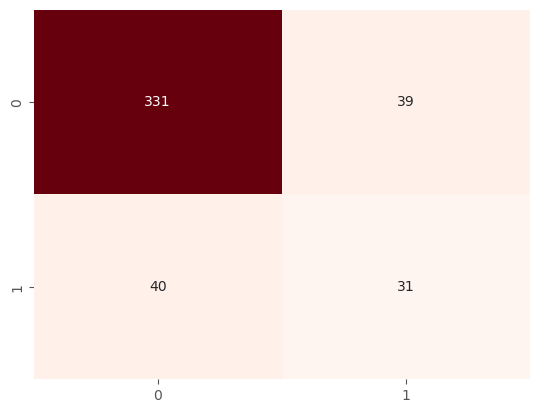

In [24]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Reds", cbar=False)
plt.show()

### ROC Curve

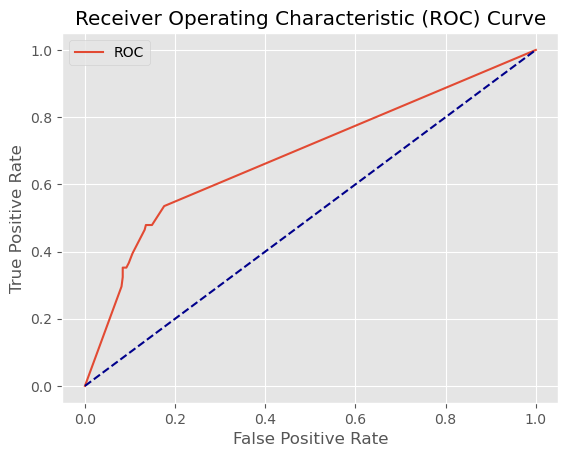

AUC: 0.69


In [25]:
from sklearn import metrics

model = DecisionTreeClassifier(criterion='entropy', max_depth=50, min_samples_leaf=2, min_samples_split=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_probs[:, 1])

plt.plot(fpr, tpr, label='ROC')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

auc = metrics.roc_auc_score(y_test, y_probs[:, 1])
print('AUC: %.2f' % auc)

## Plotting the Tree

In [26]:
from sklearn import tree

r = tree.export_text(model, feature_names=X_test.columns.tolist())
print(r)

|--- OverTime_Yes <= 0.50
|   |--- YearsWithCurrManager <= 0.50
|   |   |--- MonthlyIncome <= 2806.00
|   |   |   |--- HourlyRate <= 53.00
|   |   |   |   |--- TotalWorkingYears <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- TotalWorkingYears >  0.50
|   |   |   |   |   |--- MonthlyRate <= 19544.00
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- MonthlyRate >  19544.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- HourlyRate >  53.00
|   |   |   |   |--- StockOptionLevel <= 1.50
|   |   |   |   |   |--- Education <= 3.50
|   |   |   |   |   |   |--- DistanceFromHome <= 4.50
|   |   |   |   |   |   |   |--- Department_Research & Development <= 0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- Department_Research & Development >  0.50
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- DistanceFromHome >  4.50
|   |   |   |   |   |   |   |--- WorkLifeBalance <= 2.50
|   |   |   |   |   |   | 

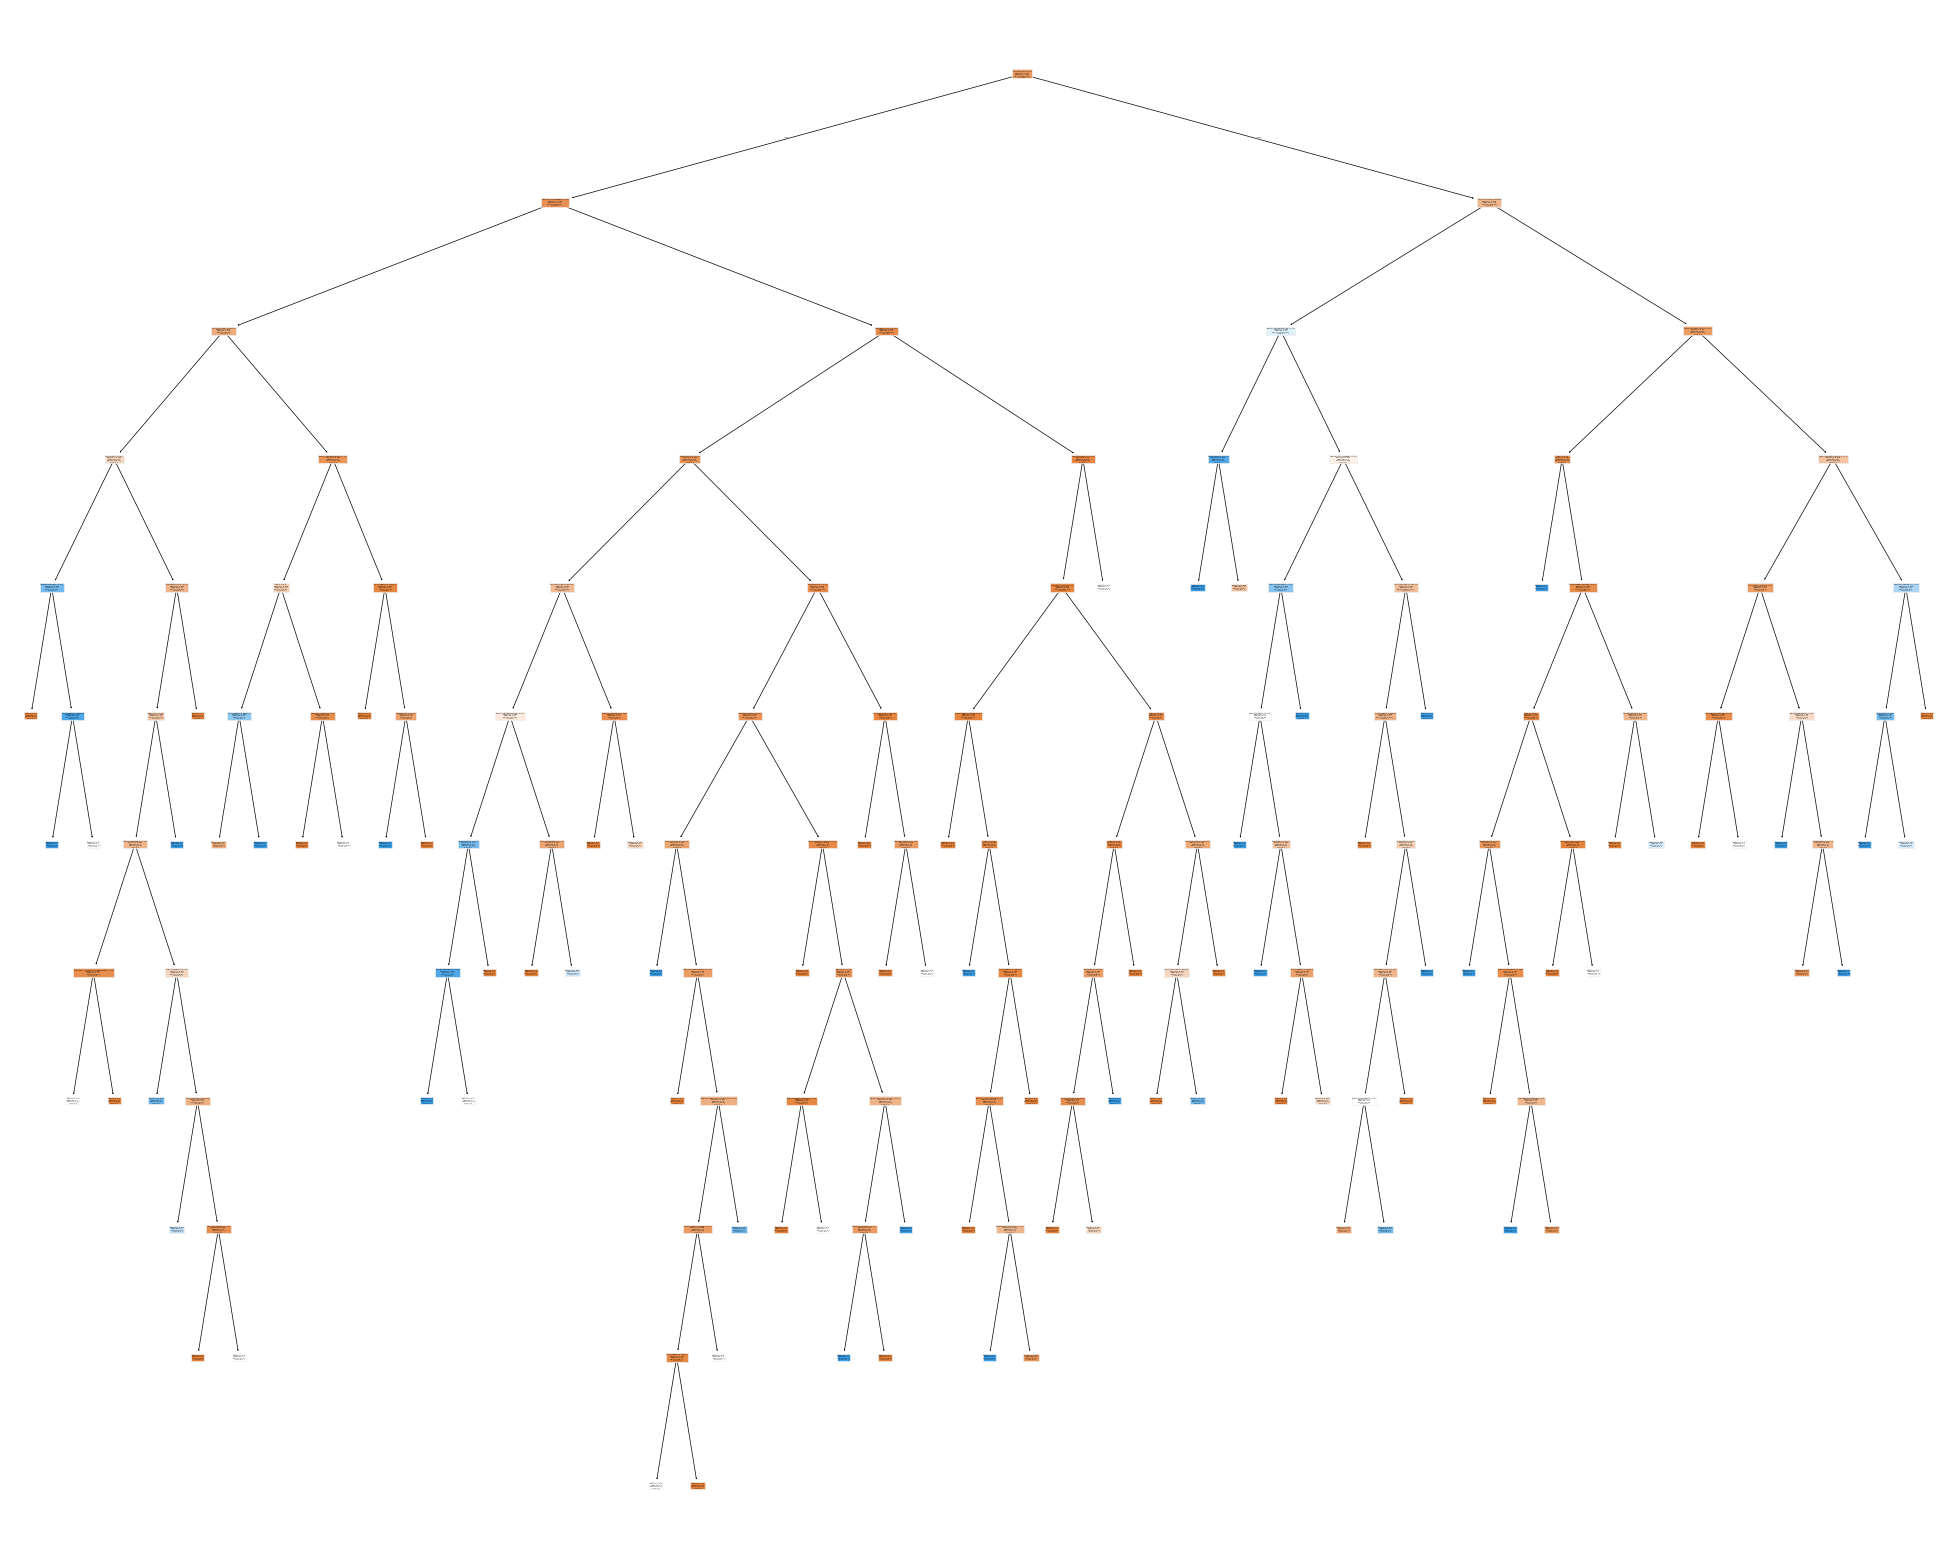

In [27]:
fig = plt.figure(figsize=(25, 20))
_ = tree.plot_tree(model,
                   feature_names=X_test.columns.tolist(),
                   class_names=['0', '1'],
                   filled=True)

## Parameter Analysis

Also in this case we can analyze the effect of a hyperparameter on the quality of the resulting model.

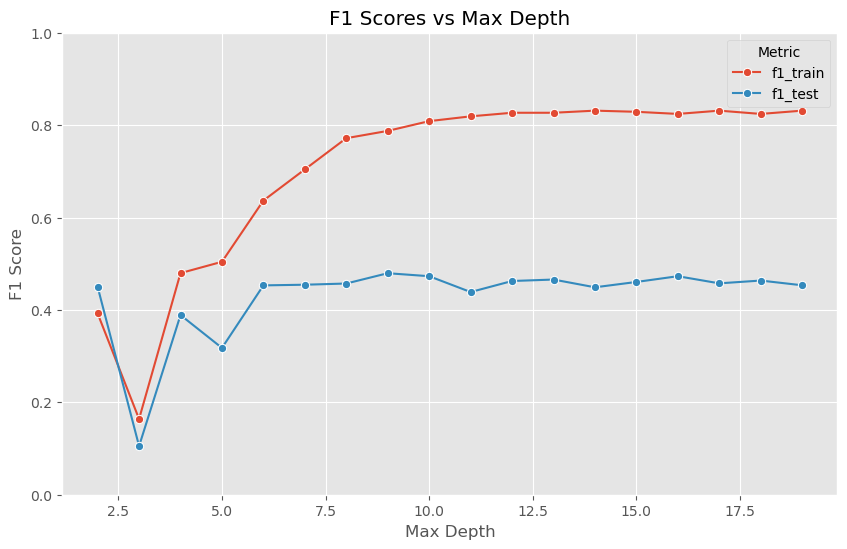

In [28]:
# Effect of max_depth
classifier = DecisionTreeClassifier(criterion='entropy', min_samples_split=5, min_samples_leaf=4)

rg = np.arange(2, 20, 1)
lst = []

for val in rg:
    classifier.max_depth = val
    classifier.fit(X_train, y_train)
    y_pred_train = classifier.predict(X_train)
    y_pred = classifier.predict(X_test)
    lst.append([val, metrics.f1_score(y_train, y_pred_train), metrics.f1_score(y_test, y_pred)])

df_depth = pd.DataFrame(lst, columns=['max_depth', 'f1_train', 'f1_test'])

df_melted = df_depth.melt(id_vars='max_depth', value_vars=['f1_train', 'f1_test'],
                           var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='max_depth', y='Score', hue='Metric', marker='o')
plt.title('F1 Scores vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('F1 Score')
plt.legend(title='Metric')
plt.grid(True)
plt.ylim(0, 1)
plt.show()

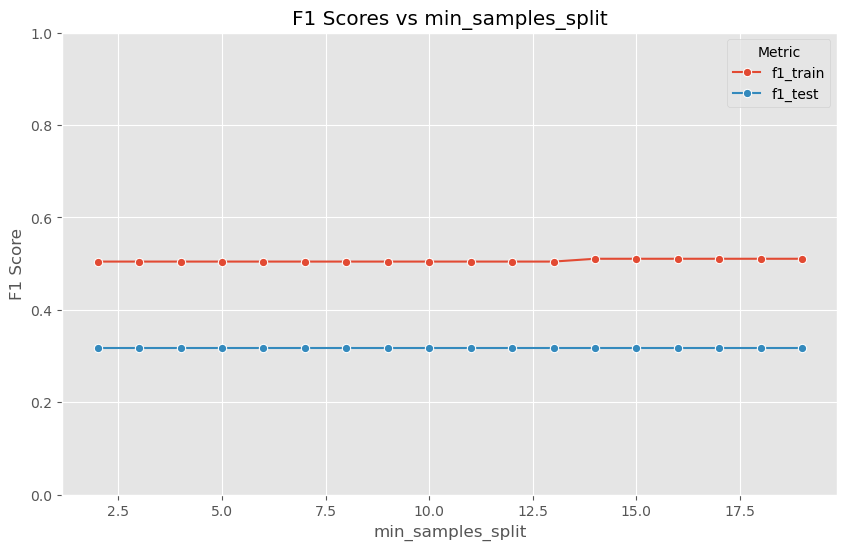

In [29]:
# Effect of min_samples_split
classifier = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=4)

rg = np.arange(2, 20, 1)
lst = []

for val in rg:
    classifier.min_samples_split = val
    classifier.fit(X_train, y_train)
    y_pred_train = classifier.predict(X_train)
    y_pred = classifier.predict(X_test)
    lst.append([val, metrics.f1_score(y_train, y_pred_train), metrics.f1_score(y_test, y_pred)])

df_split = pd.DataFrame(lst, columns=['min_samples_split', 'f1_train', 'f1_test'])

df_melted = df_split.melt(id_vars='min_samples_split', value_vars=['f1_train', 'f1_test'],
                           var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='min_samples_split', y='Score', hue='Metric', marker='o')
plt.title('F1 Scores vs min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('F1 Score')
plt.legend(title='Metric')
plt.grid(True)
plt.ylim(0, 1)
plt.show()

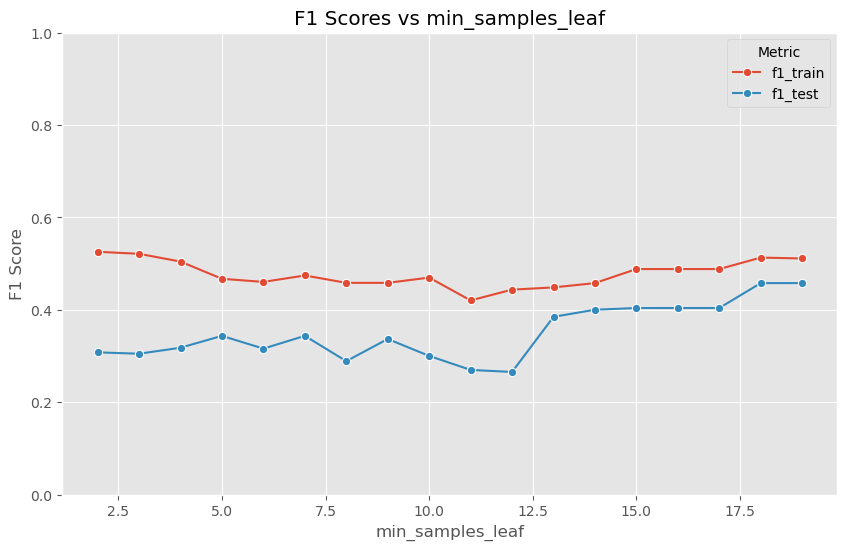

In [30]:
# Effect of min_samples_leaf
classifier = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10)

rg = np.arange(2, 20, 1)
lst = []

for val in rg:
    classifier.min_samples_leaf = val
    classifier.fit(X_train, y_train)
    y_pred_train = classifier.predict(X_train)
    y_pred = classifier.predict(X_test)
    lst.append([val, metrics.f1_score(y_train, y_pred_train), metrics.f1_score(y_test, y_pred)])

df_leaf = pd.DataFrame(lst, columns=['min_samples_leaf', 'f1_train', 'f1_test'])

df_melted = df_leaf.melt(id_vars='min_samples_leaf', value_vars=['f1_train', 'f1_test'],
                          var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_melted, x='min_samples_leaf', y='Score', hue='Metric', marker='o')
plt.title('F1 Scores vs min_samples_leaf')
plt.xlabel('min_samples_leaf')
plt.ylabel('F1 Score')
plt.legend(title='Metric')
plt.grid(True)
plt.ylim(0, 1)
plt.show()

## Summary

In this notebook we applied a Decision Tree classifier to predict employee attrition using the IBM HR dataset.

The Decision Tree showed a clear improvement over KNN from notebook 01:

- **First model** (untuned): F1 = 0.41
- **After GridSearchCV**: Best cross-validated F1 = 0.35, test F1 = 0.44, AUC = 0.69
- **Best parameters**: criterion=entropy, max_depth=50, min_samples_split=10, min_samples_leaf=2

However, overfitting remains a challenge (train F1 = 0.85 vs test F1 = 0.44). The parameter analysis revealed:

- **max_depth**: test F1 peaks around depth 9-10 (~0.49) then flattens, while train keeps climbing — deeper trees overfit
- **min_samples_split**: has little effect on the train/test gap
- **min_samples_leaf**: larger values help close the gap between train and test, pushing the model to generalize better

The Decision Tree is interpretable and significantly better than KNN on this imbalanced dataset, but its tendency to overfit motivates the use of ensemble methods in the next notebooks.